# TF-IDF入门：关键词提取Demo
这个Notebook使用TF-IDF提取每篇文档的关键词。  
读完之后，你将学习到：  
- TF（Term Frequency，词频）
- IDF（Inverse Document Frequency，逆文档频率）
- TF-IDF（Term Frequency / Inverse Document Frequency）
- 自动提取关键词
- 可视化展示结果


#### 1.准备语料
简单起见，我们用10个句子来模拟10篇文档。


In [80]:
docs = [
    "苹果 公司 发布 了 新 的 手机",
    "苹果 做 的 馅饼 是 很 好吃 的",
    "小米 也 发布 了 折叠屏 手机",
    "李玉 的 电影 苹果 提名 了 金熊奖",  
    "用 荷叶 来 包 小米 排骨",
    "天气 热 的 时候 喝 一杯 柠檬水",
    "夏天 已经 在 卖 西瓜 了",
    "火星 探测器 成功 地 发送 了 图像",
    "华为 已经 发布 了 自主 研发 的 芯片",
    "人工智能 改变 了 整个 世界"
]

#### 2.分词（Tokenization）
把句子直接按照空格进行切分。

In [81]:
corpus = [doc.split() for doc in docs]

输出示例：

In [82]:
corpus[:3]

[['苹果', '公司', '发布', '了', '新', '的', '手机'],
 ['苹果', '做', '的', '馅饼', '是', '很', '好吃', '的'],
 ['小米', '也', '发布', '了', '折叠屏', '手机']]

#### 3.构建词表（Vocabulary）
收集所有文档中出现过的单词。

In [83]:
vocab = sorted(
    set(
        word
        for doc in corpus
        for word in doc
    )
)

输出示例：

In [84]:
vocab[:10]

['一杯', '世界', '也', '了', '人工智能', '做', '公司', '包', '华为', '卖']

#### 4.计算词频（TF, Term Frequency）
TF是某个词在当前文档中出现的频率，它是词在当前文档中出现的次数和当前文档总词数的比例：
$$
TF(t, d) = \frac{n_{t,d}}{\sum_{k} n_{k,d}}
$$
其中：  
- $n_{t,d}$表示词$t$在文档$d$中出现的次数。  
- $\sum_k n_{k,d}$表示文档$d$的总词数。  

假如一篇文档中有这些单词：   
very very very good but also very very very bad  
其中very出现了6次，而总词数为10。
那么：  
$$
TF(\text{very}) = \frac{6}{10}
$$








In [85]:
from collections import Counter

tf_matrix = []

for doc in corpus:

    counter = Counter(doc)

    row = []

    for word in vocab:
        tf = counter[word] / len(doc)
        row.append(tf)

    tf_matrix.append(row)

tf_matrix[:2]

[[0.0,
  0.0,
  0.0,
  0.14285714285714285,
  0.0,
  0.0,
  0.14285714285714285,
  0.0,
  0.0,
  0.0,
  0.14285714285714285,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.14285714285714285,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.14285714285714285,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.14285714285714285,
  0.0,
  0.0,
  0.0,
  0.14285714285714285,
  0.0,
  0.0,
  0.0,
  0.0],
 [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.125,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.125,
  0.0,
  0.0,
  0.125,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.125,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.25,
  0.0,
  0.0,
  0.0,
  0.125,
  0.0,
  0.0,
  0.0,
  0.125]]

#### 5.计算逆文档频率（IDF, Inverse Document Frequency）

有些词几乎在所有文档中都会出现，它们的区分能力很弱。
因此我们引入IDF。
$$
\text{IDF}=\log(\frac{N}{DF})
$$
其中：
- N = 文档总数
- DF = 包含该词的文档数




In [86]:
import math

N = len(corpus)

idf = {}

for word in vocab:

    df = sum(
        1
        for doc in corpus
        if word in doc
    )

    idf[word] = math.log(N / (df+1))

idf

{'一杯': 1.6094379124341003,
 '世界': 1.6094379124341003,
 '也': 1.6094379124341003,
 '了': 0.22314355131420976,
 '人工智能': 1.6094379124341003,
 '做': 1.6094379124341003,
 '公司': 1.6094379124341003,
 '包': 1.6094379124341003,
 '华为': 1.6094379124341003,
 '卖': 1.6094379124341003,
 '发布': 0.9162907318741551,
 '发送': 1.6094379124341003,
 '喝': 1.6094379124341003,
 '图像': 1.6094379124341003,
 '在': 1.6094379124341003,
 '地': 1.6094379124341003,
 '夏天': 1.6094379124341003,
 '天气': 1.6094379124341003,
 '好吃': 1.6094379124341003,
 '小米': 1.2039728043259361,
 '已经': 1.2039728043259361,
 '很': 1.6094379124341003,
 '成功': 1.6094379124341003,
 '手机': 1.2039728043259361,
 '折叠屏': 1.6094379124341003,
 '排骨': 1.6094379124341003,
 '探测器': 1.6094379124341003,
 '提名': 1.6094379124341003,
 '改变': 1.6094379124341003,
 '整个': 1.6094379124341003,
 '新': 1.6094379124341003,
 '时候': 1.6094379124341003,
 '是': 1.6094379124341003,
 '李玉': 1.6094379124341003,
 '来': 1.6094379124341003,
 '柠檬水': 1.6094379124341003,
 '火星': 1.6094379124341003,
 '热': 1

#### 6.计算TF-IDF
最终公式：
$$
\text{TF-IDF}=\text{TF}\times\text{IDF}
$$
TF-IDF的公式就像是一个局部信号（TF）乘以一个全局的权重（IDF）。  
具体来说：  
- 某词在当前文档出现得越频繁，该词的TF得分越高。  
- 含有某词的文档篇数越少，该词的IDF得分越高。  



In [87]:
tfidf_matrix = []

for row in tf_matrix:

    tfidf_row = []

    for tf, word in zip(row, vocab):
        tfidf_row.append(
            tf * idf[word]
        )

    tfidf_matrix.append(tfidf_row)

转成DataFrame查看：

In [88]:
import pandas as pd

df_tfidf = pd.DataFrame(
    tfidf_matrix,
    columns=vocab,
    index=[f"doc_{i}" for i in range(len(docs))]
)

df_tfidf.head()

,一杯,世界,也,了,人工智能,做,公司,包,华为,卖,...,电影,的,研发,自主,芯片,苹果,荷叶,西瓜,金熊奖,馅饼
doc_0,0.0,0.0,0.00000,0.031878,0.0,0.00000,0.22992,0.00000,0.0,0.0,...,0.00000,0.072975,0.0,0.0,0.0,0.130899,0.00000,0.0,0.00000,0.00000
doc_1,0.0,0.0,0.00000,0.000000,0.0,0.20118,0.00000,0.00000,0.0,0.0,...,0.00000,0.127706,0.0,0.0,0.0,0.114536,0.00000,0.0,0.00000,0.20118
doc_2,0.0,0.0,0.26824,0.037191,0.0,0.00000,0.00000,0.00000,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.0,0.00000,0.00000
doc_3,0.0,0.0,0.00000,0.031878,0.0,0.00000,0.00000,0.00000,0.0,0.0,...,0.22992,0.072975,0.0,0.0,0.0,0.130899,0.00000,0.0,0.22992,0.00000
doc_4,0.0,0.0,0.00000,0.000000,0.0,0.00000,0.00000,0.26824,0.0,0.0,...,0.00000,0.000000,0.0,0.0,0.0,0.000000,0.26824,0.0,0.00000,0.00000


#### 7.提取关键词
现在做一个有趣的任务：
找出每篇文档中最能代表它的三个关键词。

In [89]:
records = []

for doc_name in df_tfidf.index:

    top_words = (
        df_tfidf.loc[doc_name]
        .sort_values(ascending=False)
        .head(3)
    )

    for word, score in top_words.items():

        records.append(
            {
                "document": doc_name,
                "word": word,
                "score": score
            }
        )

result = pd.DataFrame(records)

result.head(30)

,document,word,score
0,doc_0,公司,0.229920
1,doc_0,新,0.229920
2,doc_0,手机,0.171996
3,doc_1,做,0.201180
4,doc_1,馅饼,0.201180
5,doc_1,是,0.201180
6,doc_2,也,0.268240
7,doc_2,折叠屏,0.268240
8,doc_2,小米,0.200662
9,doc_3,提名,0.229920


观察一下，对于第一篇文档：
“苹果 公司 发布 了 新 手机”
TF-IDF找出了“公司”、“新”和“手机”作为最能代表这篇文档的三个词。 

但这里也体现了传统TF-IDF的一个缺陷——它不能识别一个词在不同语境中的不同含义。  
比如：
- "苹果 公司 发布 了 新 的 手机"
- "苹果 做 的 馅饼 是 很 好吃 的"
- "李玉 的 电影 苹果 提名 了 金熊奖"
这三个句子中的“苹果”分别是指：电脑公司的名字、水果、电影名字。但是IDF只认得它们都是由“苹"和“果”这两个汉字组成的一个词语。

#### 8.可视化关键词

把结果画出来。

/tmp/ipykernel_2074/2842373103.py:21: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2074/2842373103.py:21: UserWarning: Glyph 21496 (\N{CJK UNIFIED IDEOGRAPH-53F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2074/2842373103.py:21: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2074/2842373103.py:21: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2074/2842373103.py:21: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2074/2842373103.py:21: UserWarning: Glyph 20570 (\N{CJK UNIFIED IDEOGRAPH-505A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2074/2842373103.py:21: UserWarning: Glyph 39301 (\N{CJK UNIFIED IDEOGRAPH-9985}

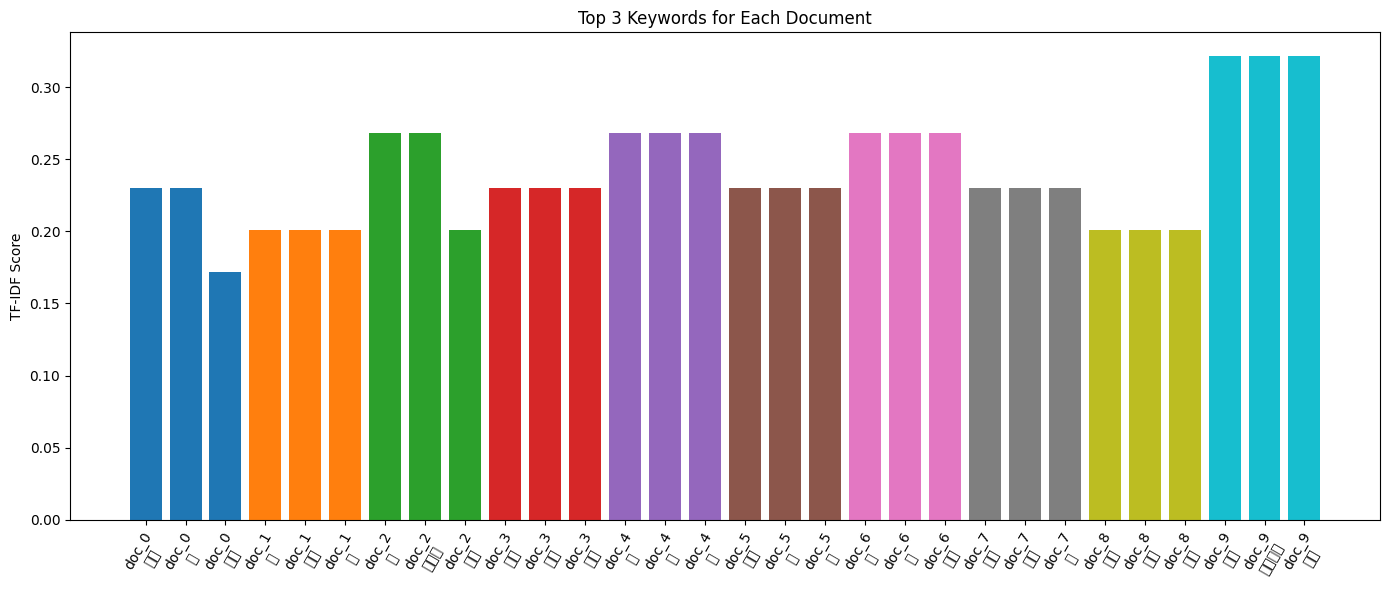

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for doc_name in result["document"].unique():

    subset = result[
        result["document"] == doc_name
    ]

    plt.bar(
        [f"{doc_name}\n{word}" for word in subset["word"]],
        subset["score"]
    )

plt.xticks(rotation=60)

plt.ylabel("TF-IDF Score")
plt.title("Top 3 Keywords for Each Document")

plt.tight_layout()

plt.show()

#### 总结

本 Notebook 完成了一个完整的小项目：

原始文本 <br>
    ↓<br>
分词<br>
    ↓<br>
构建词表<br>
    ↓<br>
计算 TF<br>
    ↓<br>
计算 IDF<br>
    ↓<br>
计算 TF-IDF<br>
    ↓<br>
关键词提取<br>
    ↓<br>
可视化展示<br>

虽然只有几十行代码，但已经实现了搜索引擎、推荐系统、文本分类等任务中的经典特征工程方法。